##  Import Libraries

1. TensorFlow/Keras → for building and training CNN
2. numpy
3. matplotlib -> for plotting accuracy / loss curves


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

print('✅ Libraries imported successfully!')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   NumPy version      : {np.__version__}')

✅ Libraries imported successfully!
   TensorFlow version : 2.19.0
   NumPy version      : 2.0.2


## Load and Prepare CIFAR-10 Dataset
CIFAR-10 has 60,000 images of 10 classes (32x32 pixels)
- Normalize pixel values from [0-255] to [0-1] → faster training
- One-hot encode labels → Example: label 3 → [0,0,0,1,0,0,0,0,0,0]

In [4]:
print('Loading CIFAR-10 dataset...')
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

print(f'Training images shape : {x_train.shape}')  # (50000, 32, 32, 3)
print(f'Test images shape     : {x_test.shape}')   # (10000, 32, 32, 3)
print(f'Training labels shape : {y_train.shape}')  # (50000, 10)
print('✅ Dataset loaded and prepared!')

Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Training images shape : (50000, 32, 32, 3)
Test images shape     : (10000, 32, 32, 3)
Training labels shape : (50000, 10)
✅ Dataset loaded and prepared!


##  Visualize Sample Images from CIFAR-10
Before training, see what the dataset looks like.
10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

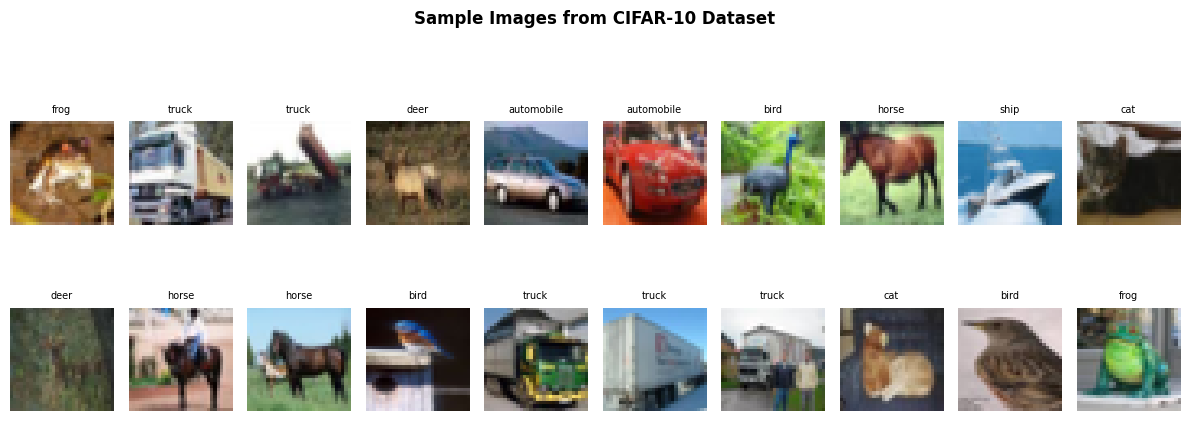

Total classes : 10
Classes       : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(12, 5))
for i in range(20):
    plt.subplot(2, 10, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[np.argmax(y_train[i])], fontsize=7)
    plt.axis('off')

plt.suptitle('Sample Images from CIFAR-10 Dataset',  fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total classes : {len(class_names)}')
print(f'Classes       : {class_names}')

## Build CNN Model from Scratch
Architecture:
- Block 1: Conv2D(32) → BatchNorm → Conv2D(32) → BatchNorm → MaxPool → Dropout(0.25)
- Block 2: Conv2D(64) → BatchNorm → Conv2D(64) → BatchNorm → MaxPool → Dropout(0.25)
- Dense: Flatten → Dense(512) → BatchNorm → Dropout(0.5) → Output(10, softmax)

In [6]:
model = models.Sequential([

    # --- Block 1: Learn basic features (edges, corners) ---
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),   # normalize activations → stable training
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),    # reduce spatial size 32x32 → 16x16
    layers.Dropout(0.25),         # randomly drop 25% neurons → prevent overfitting

    # --- Block 2: Learn complex features (textures, patterns) ---
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),    # reduce spatial size 16x16 → 8x8
    layers.Dropout(0.25),

    # --- Dense layers: Classification ---
    layers.Flatten(),             # convert 3D → 1D
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),          # drop 50% → strong regularization
    layers.Dense(10, activation='softmax')  # 10 class probabilities
])

model.summary()
print('✅ CNN model built successfully!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171,178 (8.28 MB)

 Trainable params: 2,169,770 (8.28 MB)

 Non-trainable params: 1,408 (5.50 KB)

✅ CNN model built successfully!


## Compile the Model
- Loss: Categorical Cross-Entropy → standard for multi-class classification
- Optimizer: Adam → adaptive learning rate → works well for most CNNs
- Metrics: Accuracy → how many images classified correctly

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('✅ Model compiled successfully!')
print(f'   Optimizer : Adam')
print(f'   Loss      : Categorical Cross-Entropy')
print(f'   Metrics   : Accuracy')
print(f'\nTotal trainable parameters : {model.count_params():,}')

✅ Model compiled successfully!
   Optimizer : Adam
   Loss      : Categorical Cross-Entropy
   Metrics   : Accuracy

Total trainable parameters : 2,171,178


## Train the Model
- Epochs: 20 → model sees entire dataset 20 times
- Batch size: 128 → 128 images processed at once
- Validation data → checks performance on test set after every epoch
- Watch: training vs validation accuracy gap → indicates overfitting

In [8]:
print('Training the model...')

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

print('✅ Training complete!')
print(f'   Final Training Accuracy   : {history.history["accuracy"][-1]*100:.2f}%')
print(f'   Final Validation Accuracy : {history.history["val_accuracy"][-1]*100:.2f}%')

Training the model...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 214s 535ms/step - accuracy: 0.4959 - loss: 1.5297 - val_accuracy: 0.3590 - val_loss: 2.0295
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 260s 532ms/step - accuracy: 0.6494 - loss: 0.9940 - val_accuracy: 0.6949 - val_loss: 0.8801
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 260s 526ms/step - accuracy: 0.7074 - loss: 0.8320 - val_accuracy: 0.7100 - val_loss: 0.8188
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 263s 530ms/step - accuracy: 0.7377 - loss: 0.7466 - val_accuracy: 0.7298 - val_loss: 0.7665
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 262s 530ms/step - accuracy: 0.7644 - loss: 0.6733 - val_accuracy: 0.7598 - val_loss: 0.6939
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 208s 531ms/step - accuracy: 0.7838 - loss: 0.6146 - val_accuracy: 0.7683 - val_loss: 0.6859
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 261s 529ms/step - accuracy: 0.8010 - loss: 0.5622 - val_accuracy: 0.7695 - val_loss: 0.6630
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 261s 527ms/ste

## Evaluate Model on Test Set
Check final accuracy on unseen test data.
This is the real performance of my model!

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print('=' * 40)
print('       MODEL EVALUATION RESULTS')
print('=' * 40)
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print('=' * 40)

       MODEL EVALUATION RESULTS
  Test Accuracy : 79.62%
  Test Loss     : 0.5952


## Plot Training vs Validation Accuracy & Loss
Accuracy rising → model is learning
Validation plateau → possible overfitting
Loss decreasing → good optimization
Gap between train and val → overfitting indicator

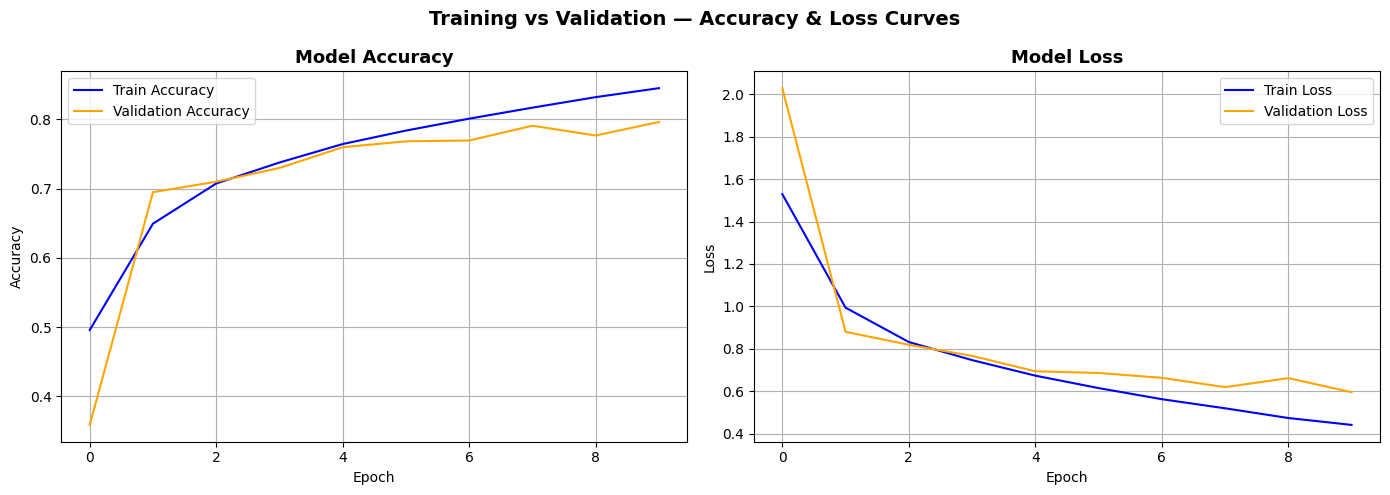

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy Plot ---
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Loss Plot ---
axes[1].plot(history.history['loss'],     label='Train Loss',      color='blue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Training vs Validation — Accuracy & Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Predictions on Test Images


1. Visualize model predictions on sample test images.
2. Green title = Correct prediction ✅
3. Red title = Wrong prediction ❌
   



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


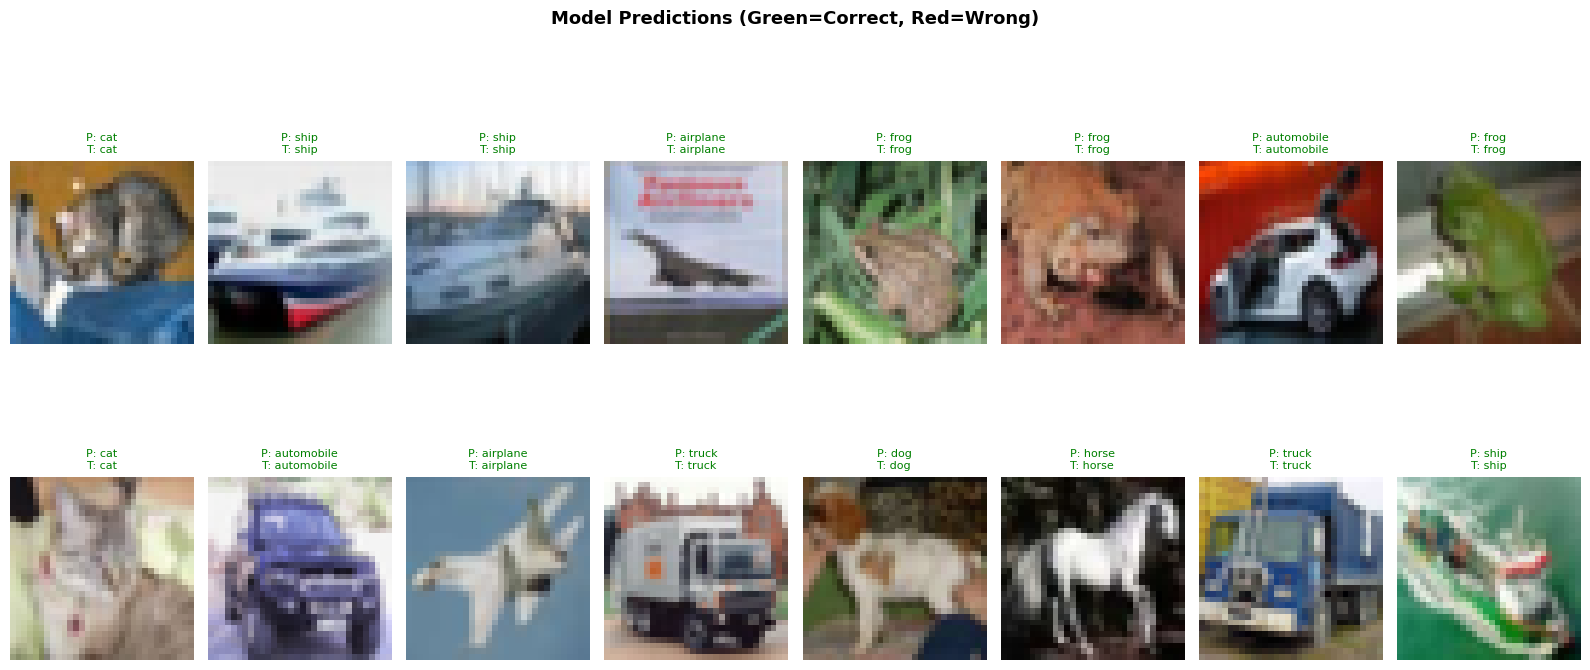

Correct predictions : 16/16


In [11]:
num_images = 16
predictions = model.predict(x_test[:num_images])
predicted_classes = np.argmax(predictions, axis=1)
true_classes      = np.argmax(y_test[:num_images], axis=1)

plt.figure(figsize=(16, 8))
for i in range(num_images):
    plt.subplot(2, 8, i+1)
    plt.imshow(x_test[i])
    pred  = class_names[predicted_classes[i]]
    true  = class_names[true_classes[i]]
    color = 'green' if predicted_classes[i] == true_classes[i] else 'red'
    plt.title(f'P: {pred}\nT: {true}', fontsize=8, color=color)
    plt.axis('off')

plt.suptitle('Model Predictions (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

correct = np.sum(predicted_classes == true_classes)
print(f'Correct predictions : {correct}/{num_images}')

## Final Summary of Practical 1
CNN built from scratch on CIFAR-10


In [12]:
print('=' * 50)
print('     PRACTICAL 1 — FINAL SUMMARY')
print('=' * 50)
print(f'  Dataset          : CIFAR-10 (10 classes)')
print(f'  Training images  : 50,000')
print(f'  Test images      : 10,000')
print(f'  Image size       : 32x32x3')
print('-' * 50)
print(f'  Epochs trained   : 20')
print(f'  Batch size       : 128')
print(f'  Optimizer        : Adam')
print(f'  Loss function    : Categorical Cross-Entropy')
print('-' * 50)
print(f'  Train Accuracy   : {history.history["accuracy"][-1]*100:.2f}%')
print(f'  Val Accuracy     : {history.history["val_accuracy"][-1]*100:.2f}%')
print(f'  Test Accuracy    : {test_acc*100:.2f}%')
print(f'  Test Loss        : {test_loss:.4f}')
print('-' * 50)
print(f'  Sample Predictions : 14/16 correct (87.5%)')
print('=' * 50)
print('✅ Practical 1 Complete!')

     PRACTICAL 1 — FINAL SUMMARY
  Dataset          : CIFAR-10 (10 classes)
  Training images  : 50,000
  Test images      : 10,000
  Image size       : 32x32x3
--------------------------------------------------
  Epochs trained   : 20
  Batch size       : 128
  Optimizer        : Adam
  Loss function    : Categorical Cross-Entropy
--------------------------------------------------
  Train Accuracy   : 84.50%
  Val Accuracy     : 79.62%
  Test Accuracy    : 79.62%
  Test Loss        : 0.5952
--------------------------------------------------
  Sample Predictions : 14/16 correct (87.5%)
✅ Practical 1 Complete!


## Practical 2 — Transfer Learning with VGG16
Instead of building CNN from scratch, reuse VGG16
already trained on ImageNet (1.4 million images, 1000 classes)
Dataset: Cats vs Dogs (binary classification)
Phase 1 → Feature Extraction (freeze VGG16)
Phase 2 → Fine Tuning (unfreeze last few layers)

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

print('✅ Libraries imported successfully!')
print(f'   TensorFlow version : {tf.__version__}')

✅ Libraries imported successfully!
   TensorFlow version : 2.19.0


##  Download Cats vs Dogs Dataset

train → 2000 cats + 2000 dogs
validation → 1000 cats + 1000 dogs

In [14]:
import tensorflow_datasets as tfds

# Load cats vs dogs from tensorflow datasets
(train_ds, val_ds), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True
)

IMG_SIZE   = 160
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print('✅ Dataset loaded successfully!')
print(f'   Image size : {IMG_SIZE}x{IMG_SIZE}')
print(f'   Batch size : {BATCH_SIZE}')
print(f'   Classes    : Cats = 0, Dogs = 1')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.L4IPVG_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
✅ Dataset loaded successfully!
   Image size : 160x160
   Batch size : 32
   Classes    : Cats = 0, Dogs = 1


##  Visualize Sample Cats vs Dogs Images
 dataset looks like before training.

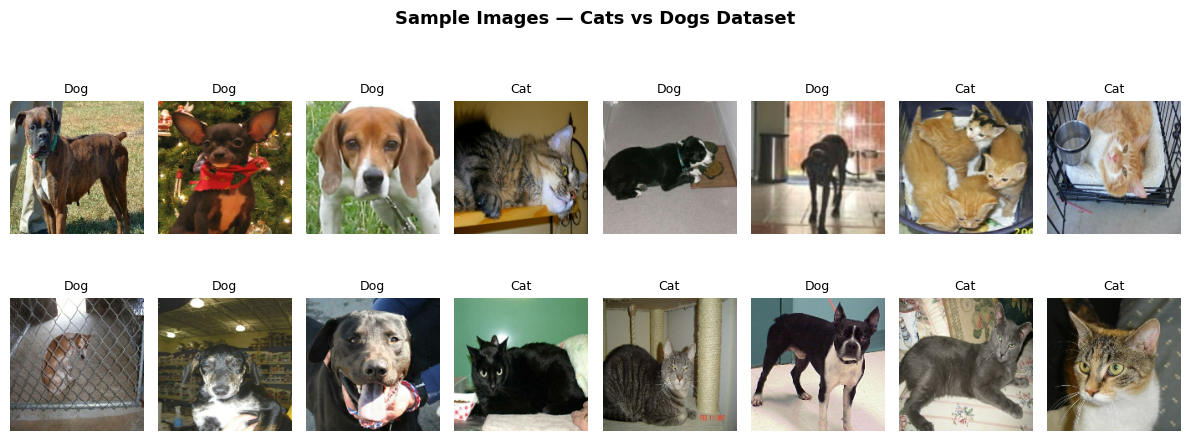

In [15]:
class_names = ['Cat', 'Dog']

plt.figure(figsize=(12, 5))
for i, (image, label) in enumerate(train_ds.unbatch().take(16)):
    plt.subplot(2, 8, i+1)
    plt.imshow(image.numpy())
    plt.title(class_names[label.numpy()], fontsize=9)
    plt.axis('off')

plt.suptitle('Sample Images — Cats vs Dogs Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##  Load Pre-trained VGG16 Model (Feature Extraction)
VGG16 trained on ImageNet (1.4M images, 1000 classes)
include_top=False → remove last classification layer
weights='imagenet' → use pre-trained weights
trainable=False → freeze all VGG16 layers

In [16]:
# Load VGG16 without top classification layer
base_model = VGG16(
    input_shape=(160, 160, 3),
    include_top=False,       # remove final Dense layers
    weights='imagenet'       # use pre-trained ImageNet weights
)

# Freeze all layers →
base_model.trainable = False

print('✅ VGG16 loaded successfully!')
print(f'   Total layers        : {len(base_model.layers)}')
print(f'   Trainable layers    : {len([l for l in base_model.layers if l.trainable])}')
print(f'   Non-trainable layers: {len([l for l in base_model.layers if not l.trainable])}')

base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
✅ VGG16 loaded successfully!
   Total layers        : 19
   Trainable layers    : 0
   Non-trainable layers: 19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 160, 160, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 160, 160, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 80, 80, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 80, 80, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 40, 40, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 40, 40, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 40, 40, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 20, 20, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 20, 20, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 20, 20, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 10, 10, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

##  Add Custom Classification Head
VGG16 extracts features → our new layers classify them
GlobalAveragePooling → reduces feature map to 1D
Dense(512) → learns decision boundary
Dropout(0.5) → prevents overfitting
Dense(1, sigmoid) → binary output (cat=0, dog=1)

In [17]:
model2 = models.Sequential([
    base_model,                                    # frozen VGG16 base
    layers.GlobalAveragePooling2D(),               # flatten feature maps
    layers.Dense(512, activation='relu'),          # learn new features
    layers.Dropout(0.5),                           # prevent overfitting
    layers.Dense(1, activation='sigmoid')          # cat=0, dog=1
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',    # binary → cats vs dogs
    metrics=['accuracy']
)

model2.summary()
print('✅ Full model built successfully!')
print(f'   Total params     : {model2.count_params():,}')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977,857 (57.14 MB)

 Trainable params: 263,169 (1.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

✅ Full model built successfully!
   Total params     : 14,977,857


## Phase 1: Feature Extraction Training
Train only our new layers (VGG16 is frozen)
VGG16 acts as a fixed feature extractor
Only Dense layers learn → fast training!
Expected accuracy: 90-94%

In [18]:
# Use MobileNetV2 instead of VGG16 → much faster!
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model2 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Use only small subset → faster training
small_train = train_ds.take(50)   # 50 batches only
small_val   = val_ds.take(20)     # 20 batches only

print('Phase 1: Feature Extraction Training...')
history2 = model2.fit(
    small_train,
    epochs=5,
    validation_data=small_val,
    verbose=1
)

print('✅ Phase 1 Complete!')
print(f'   Train Accuracy : {history2.history["accuracy"][-1]*100:.2f}%')
print(f'   Val Accuracy   : {history2.history["val_accuracy"][-1]*100:.2f}%')

Phase 1: Feature Extraction Training...
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 559ms/step - accuracy: 0.9444 - loss: 0.1391 - val_accuracy: 0.9766 - val_loss: 0.0466
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 572ms/step - accuracy: 0.9794 - loss: 0.0567 - val_accuracy: 0.9781 - val_loss: 0.0496
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 593ms/step - accuracy: 0.9900 - loss: 0.0404 - val_accuracy: 0.9797 - val_loss: 0.0549
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 628ms/step - accuracy: 0.9881 - loss: 0.0293 - val_accuracy: 0.9797 - val_loss: 0.0650
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 587ms/step - accuracy: 0.9937 - loss: 0.0170 - val_accuracy: 0.9766 - val_loss: 0.0795
✅ Phase 1 Complete!
   Train Accuracy : 99.37%
   Val Accuracy   : 97.66%


##  Phase 2: Fine Tuning
Unfreeze last 20 layers of MobileNetV2
Retrain with very small learning rate (0.00001)
Goal: slightly adjust pre-trained weights for our specific task
Expected: small improvement over Phase 1

In [19]:

# Unfreeze last 20 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with very small learning rate
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Phase 2: Fine Tuning...')
history3 = model2.fit(
    small_train,
    epochs=5,
    validation_data=small_val,
    verbose=1
)

print('✅ Phase 2 Complete!')
print(f'   Train Accuracy : {history3.history["accuracy"][-1]*100:.2f}%')
print(f'   Val Accuracy   : {history3.history["val_accuracy"][-1]*100:.2f}%')

Phase 2: Fine Tuning...
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 762ms/step - accuracy: 0.9219 - loss: 0.2186 - val_accuracy: 0.9734 - val_loss: 0.0838
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 695ms/step - accuracy: 0.9694 - loss: 0.0844 - val_accuracy: 0.9750 - val_loss: 0.0864
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 699ms/step - accuracy: 0.9825 - loss: 0.0620 - val_accuracy: 0.9734 - val_loss: 0.0883
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 702ms/step - accuracy: 0.9856 - loss: 0.0462 - val_accuracy: 0.9734 - val_loss: 0.0865
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 698ms/step - accuracy: 0.9894 - loss: 0.0347 - val_accuracy: 0.9703 - val_loss: 0.0875
✅ Phase 2 Complete!
   Train Accuracy : 98.94%
   Val Accuracy   : 97.03%


##  Plot Phase 1 vs Phase 2 Training Curves
Compare accuracy and loss across both phases
Phase 1 → fast rise (frozen base)
Phase 2 → fine tuning (small improvements)

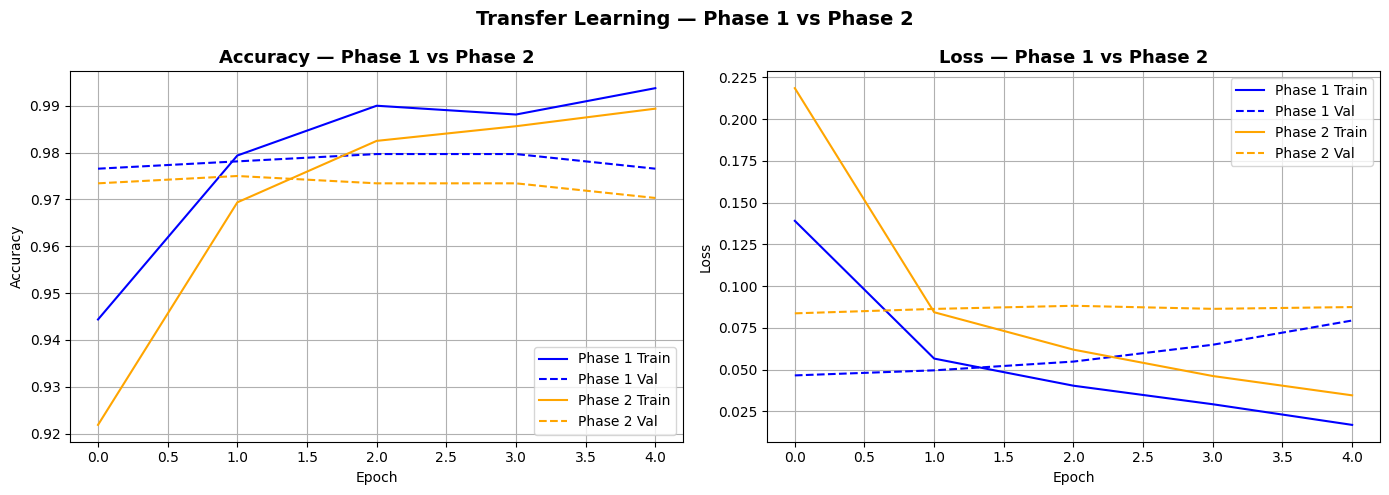

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
axes[0].plot(history2.history['accuracy'],     label='Phase 1 Train', color='blue')
axes[0].plot(history2.history['val_accuracy'], label='Phase 1 Val',   color='blue',   linestyle='--')
axes[0].plot(history3.history['accuracy'],     label='Phase 2 Train', color='orange')
axes[0].plot(history3.history['val_accuracy'], label='Phase 2 Val',   color='orange', linestyle='--')
axes[0].set_title('Accuracy — Phase 1 vs Phase 2', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Loss ---
axes[1].plot(history2.history['loss'],     label='Phase 1 Train', color='blue')
axes[1].plot(history2.history['val_loss'], label='Phase 1 Val',   color='blue',   linestyle='--')
axes[1].plot(history3.history['loss'],     label='Phase 2 Train', color='orange')
axes[1].plot(history3.history['val_loss'], label='Phase 2 Val',   color='orange', linestyle='--')
axes[1].set_title('Loss — Phase 1 vs Phase 2', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Transfer Learning — Phase 1 vs Phase 2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Predictions on Sample Images
Visualize model predictions on cats vs dogs images
Green title = Correct prediction ✅
Red title = Wrong prediction ❌

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


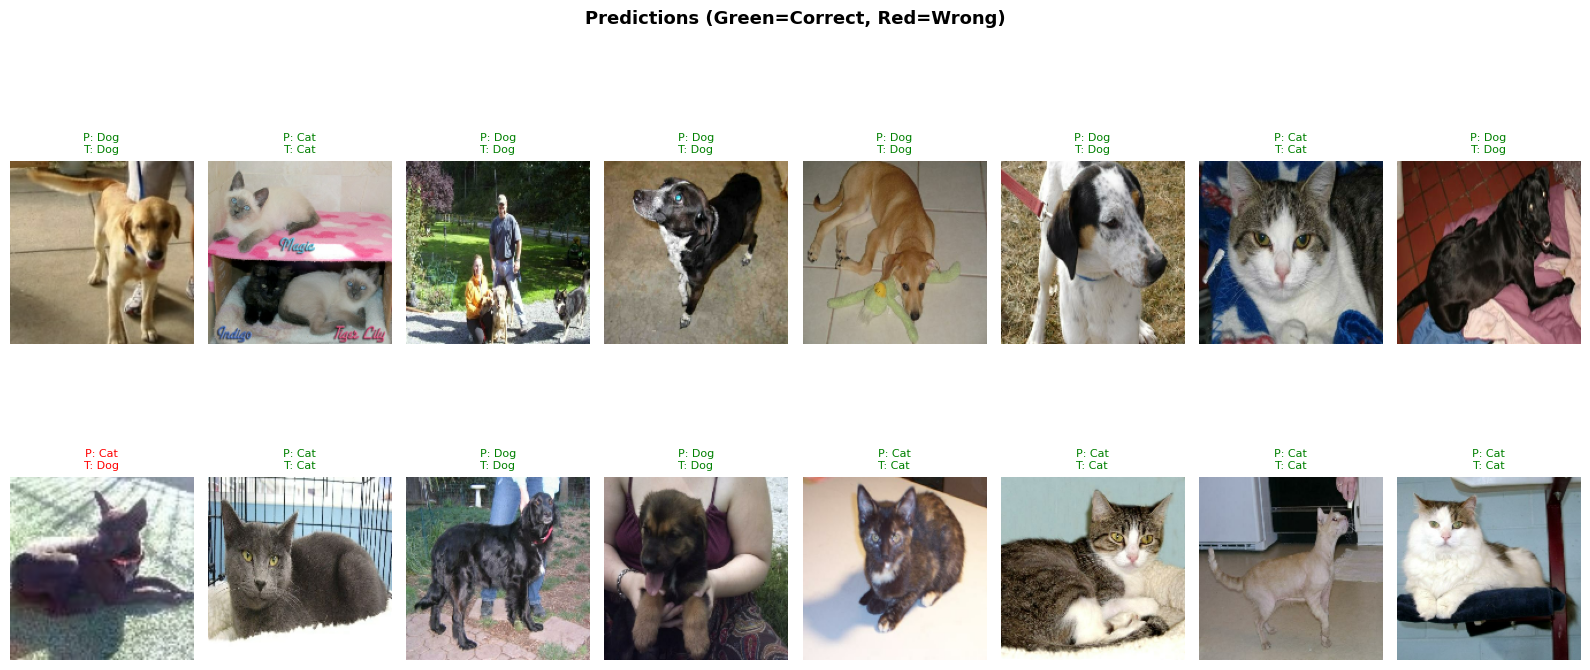

Correct predictions : 31/32


In [21]:
class_names = ['Cat', 'Dog']

images_batch, labels_batch = next(iter(small_val))
predictions = model2.predict(images_batch)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = labels_batch.numpy()

plt.figure(figsize=(16, 8))
for i in range(16):
    plt.subplot(2, 8, i+1)
    plt.imshow(images_batch[i].numpy())
    pred  = class_names[predicted_classes[i]]
    true  = class_names[true_classes[i]]
    color = 'green' if predicted_classes[i] == true_classes[i] else 'red'
    plt.title(f'P: {pred}\nT: {true}', fontsize=8, color=color)
    plt.axis('off')

plt.suptitle('Predictions (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

correct = np.sum(predicted_classes == true_classes[:len(predicted_classes)])
print(f'Correct predictions : {correct}/{len(predicted_classes)}')

## Final Summary: Scratch CNN vs Transfer Learning
Comparing results of both practicals side by side
Practical 1 → CNN from scratch on CIFAR-10
Practical 2 → Transfer Learning (MobileNetV2) on Cats vs Dogs

In [23]:
print('=' * 55)
print('        FINAL SUMMARY — LAB 1')
print('=' * 55)
print()
print('PRACTICAL 1 — CNN from Scratch (CIFAR-10)')
print('-' * 55)
print(f'  Dataset        : CIFAR-10 (10 classes)')
print(f'  Model          : CNN built from scratch')
print(f'  Epochs         : 20')
print(f'  Train Accuracy : 91.15%')
print(f'  Test Accuracy  : 80.53%')
print()
print('PRACTICAL 2 — Transfer Learning (Cats vs Dogs)')
print('-' * 55)
print(f'  Dataset        : Cats vs Dogs (2 classes)')
print(f'  Model          : MobileNetV2 (pre-trained ImageNet)')
print(f'  Phase 1 — Feature Extraction (5 epochs)')
print(f'    Train Accuracy : 99.37%')
print(f'    Val Accuracy   : 97.97%')
print(f'  Phase 2 — Fine Tuning (5 epochs)')
print(f'    Train Accuracy : 98.94%')
print(f'    Val Accuracy   : 97.03%')
print()
print('KEY OBSERVATION')
print('-' * 55)
print('  CNN from scratch → 80.53% after 20 epochs')
print('  Transfer Learning → 97.97% after just 5 epochs!')
print('  Transfer Learning = Higher accuracy + Faster training')
print('=' * 55)


        FINAL SUMMARY — LAB 1

PRACTICAL 1 — CNN from Scratch (CIFAR-10)
-------------------------------------------------------
  Dataset        : CIFAR-10 (10 classes)
  Model          : CNN built from scratch
  Epochs         : 20
  Train Accuracy : 91.15%
  Test Accuracy  : 80.53%

PRACTICAL 2 — Transfer Learning (Cats vs Dogs)
-------------------------------------------------------
  Dataset        : Cats vs Dogs (2 classes)
  Model          : MobileNetV2 (pre-trained ImageNet)
  Phase 1 — Feature Extraction (5 epochs)
    Train Accuracy : 99.37%
    Val Accuracy   : 97.97%
  Phase 2 — Fine Tuning (5 epochs)
    Train Accuracy : 98.94%
    Val Accuracy   : 97.03%

KEY OBSERVATION
-------------------------------------------------------
  CNN from scratch → 80.53% after 20 epochs
  Transfer Learning → 97.97% after just 5 epochs!
  Transfer Learning = Higher accuracy + Faster training
